# mask-to-mri — Synthetic MRI Generation with pix2pix

This notebook runs the full pipeline: data exploration → preprocessing → model training → evaluation.

**Experiment A:** Train pix2pix to generate realistic MRI from masks.  
**Experiment B:** Measure segmentation improvement with synthetic data.

## 0 — Setup & Config

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

os.chdir('/content')
!git clone https://github.com/AmineAitLaamim/Mask-to-MRI
%cd Mask-to-MRI

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'Mask-to-MRI' already exists and is not an empty directory.
/content/Mask-to-MRI


In [16]:
import os

os.chdir('/content')
if not os.path.exists('Mask-to-MRI'):
    !git clone https://github.com/AmineAitLaamim/Mask-to-MRI

%cd Mask-to-MRI

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Dataset symlink
os.makedirs('data/raw', exist_ok=True)
if not os.path.exists('data/raw/lgg-mri-segmentation'):
    os.symlink(
        '/content/drive/MyDrive/mask-to-mri/dataset/lgg-mri-segmentation',
        'data/raw/lgg-mri-segmentation'
    )

# Create outputs dir, then symlink subdirs
os.makedirs('outputs', exist_ok=True)
for d in ['checkpoints', 'samples', 'metrics']:
    local = f'outputs/{d}'
    remote = f'/content/drive/MyDrive/mask-to-mri/outputs/{d}'
    os.makedirs(remote, exist_ok=True)
    if os.path.islink(local) or os.path.exists(local):
        os.remove(local) if os.path.islink(local) else None
    os.symlink(remote, local, target_is_directory=True)

# !pip install -q -r requirements.txt
!pip install -q torch torchvision albumentations opencv-python tifffile scikit-image pytorch-fid segmentation-models-pytorch pyyaml matplotlib numpy Pillow tqdm

print(f"Dir: {os.getcwd()}")
print("Files:", os.listdir('.'))

/content/Mask-to-MRI
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:00
Dir: /content/Mask-to-MRI
Files: ['data', 'src', 'mask_to_mri.ipynb', 'pyproject.toml', '.git', 'README.md', '.python-version', 'uv.lock', 'notebooks', 'outputs', '.gitignore', 'config.yaml', 'main.py']


In [26]:
import sys
sys.path.insert(0, '.')

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load config
with open('config.yaml') as f:
    config = yaml.safe_load(f)

print("Configuration:")
print(yaml.dump(config, default_flow_style=False))

# Fix seeds
from src.utils import fix_seed, get_device
fix_seed(config['data']['seed'])
device = get_device()

Configuration:
data:
  image_size: 256
  processed_dir: data/processed
  raw_dir: data/raw/lgg-mri-segmentation
  seed: 42
  synthetic_dir: data/synthetic
model:
  input_channels: 1
  norm: instance
  num_filters: 64
  output_channels: 3
paths:
  checkpoints: outputs/checkpoints
  metrics: outputs/metrics
  samples: outputs/samples
training:
  batch_size: 1
  beta1: 0.5
  beta2: 0.999
  epochs: 200
  lambda_l1: 100
  lr: 0.0002
  save_every: 5

  → Random seed fixed: 42
  → Device: cuda


## 1 — Data Exploration

In [27]:
from src.dataset import get_patient_file_list
import tifffile
import os

raw_dir = config['data']['raw_dir']
patient_data = get_patient_file_list(raw_dir)

print(f"Total patients: {len(patient_data)}")
print(f"Sample patients: {list(patient_data.keys())[:5]}")

total_slices = sum(len(v) for v in patient_data.values())
slices_per_patient = [len(v) for v in patient_data.values()]
print(f"Total slices: {total_slices}")
print(f"Slices per patient: min={min(slices_per_patient)}, max={max(slices_per_patient)}, avg={np.mean(slices_per_patient):.1f}")

Total patients: 90
Sample patients: ['TCGA_DU_5854_19951104', 'TCGA_DU_5855_19951217', 'TCGA_DU_5871_19941206', 'TCGA_DU_5872_19950223', 'TCGA_DU_5874_19950510']
Total slices: 3386
Slices per patient: min=1, max=88, avg=37.6


Patient: TCGA_DU_5854_19951104
Tumor slice index: 13
Image shape: (256, 256, 3), dtype: uint8
Mask shape: (256, 256), dtype: uint8
  R/T1: min=0, max=134, mean=15.9
  G/FLAIR: min=0, max=170, mean=19.5
  B/T2: min=0, max=148, mean=16.1
Mask values: [  0 255]


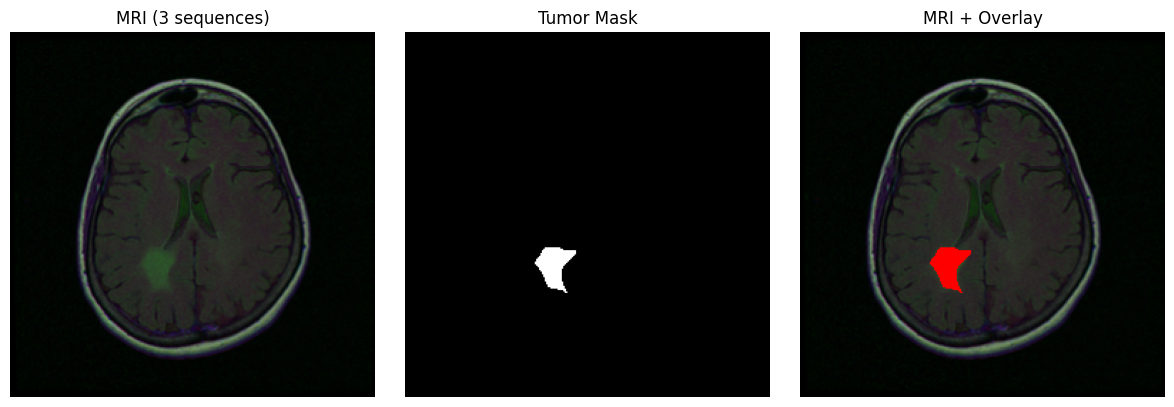

In [29]:
import numpy as np
import os
import tifffile
import matplotlib.pyplot as plt

# Find a slice with tumor pixels
first_patient = list(patient_data.keys())[0]
p_dir = '/content/drive/MyDrive/mask-to-mri/dataset/lgg-mri-segmentation/' + first_patient

mask_files = sorted([f for f in os.listdir(p_dir) if f.endswith('_mask.tif')])

# Find first mask with tumor
tumor_idx = None
for i, mf in enumerate(mask_files):
    m = tifffile.imread(os.path.join(p_dir, mf))
    if m.max() > 0:
        tumor_idx = i
        mask_path = os.path.join(p_dir, mf)
        img_path = os.path.join(p_dir, mf.replace('_mask.tif', '.tif'))
        break

if tumor_idx is None:
    print("No tumor found in first patient, skipping.")
else:
    image = tifffile.imread(img_path)
    mask = tifffile.imread(mask_path)

    print(f"Patient: {first_patient}")
    print(f"Tumor slice index: {tumor_idx}")
    print(f"Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")

    for i, ch in enumerate(['R/T1', 'G/FLAIR', 'B/T2']):
        print(f"  {ch}: min={image[:,:,i].min()}, max={image[:,:,i].max()}, mean={image[:,:,i].mean():.1f}")
    print(f"Mask values: {np.unique(mask)}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title('MRI (3 sequences)')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Tumor Mask')
    axes[1].axis('off')

    overlay = image.copy()
    overlay[mask > 0] = [255, 0, 0]
    axes[2].imshow(overlay)
    axes[2].set_title('MRI + Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## 2 — Dataset & DataLoaders

In [30]:
from src.dataset import build_dataloaders

loaders = build_dataloaders(
    raw_dir=config['data']['raw_dir'],
    image_size=config['data']['image_size'],
    batch_size=config['training']['batch_size'],
    num_workers=0,
    seed=config['data']['seed'],
)

  Train: 72 patients, 2664 slices
  Val:   9 patients, 354 slices
  Test:  9 patients, 368 slices


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


  train: 949 samples after filtering
  val: 126 samples after filtering
  test: 122 samples after filtering


Mask tensor: torch.Size([1, 1, 256, 256])  (B, C, H, W)
Image tensor: torch.Size([1, 3, 256, 256])  (B, C, H, W)
Mask range: [-1.00, 1.00]
Image range: [-1.00, 0.39]


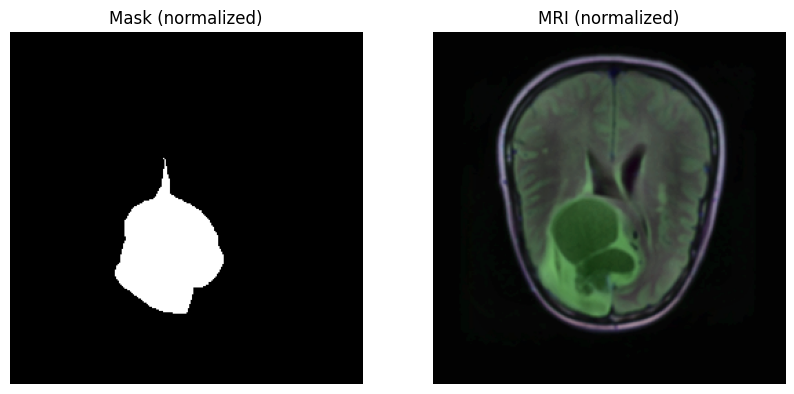

In [31]:
# Verify tensor shapes and visualize a batch
mask, img = next(iter(loaders['train']))
print(f"Mask tensor: {mask.shape}  (B, C, H, W)")
print(f"Image tensor: {img.shape}  (B, C, H, W)")
print(f"Mask range: [{mask.min():.2f}, {mask.max():.2f}]")
print(f"Image range: [{img.min():.2f}, {img.max():.2f}]")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mask_vis = ((mask[0, 0].numpy() + 1.0) * 127.5).astype(np.uint8)
img_vis = ((img[0].numpy().transpose(1, 2, 0) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
axes[0].imshow(mask_vis, cmap='gray')
axes[0].set_title('Mask (normalized)')
axes[0].axis('off')
axes[1].imshow(img_vis)
axes[1].set_title('MRI (normalized)')
axes[1].axis('off')
plt.show()

## 3 — Model Architecture

In [32]:
import torch
from src.generator import create_generator
from src.discriminator import create_discriminator
from src.utils import print_model_summary

torch.cuda.empty_cache()  # clean memory first

model_cfg = config['model']

G = create_generator(
    in_channels=model_cfg['input_channels'],
    out_channels=model_cfg['output_channels'],
    num_filters=model_cfg['num_filters'],
    norm=model_cfg['norm'],
).to(device)

D = create_discriminator(
    in_channels=model_cfg['input_channels'] + model_cfg['output_channels'],
    num_filters=model_cfg['num_filters'],
).to(device)

# Verify device placement
assert next(G.parameters()).device.type == device.type, "Generator not on GPU!"
assert next(D.parameters()).device.type == device.type, "Discriminator not on GPU!"

print_model_summary('Generator (U-Net)', G)
print_model_summary('Discriminator (PatchGAN)', D)

# Quick forward pass test
mask_test = torch.randn(1, 1, 256, 256).to(device)
img_test = torch.randn(1, 3, 256, 256).to(device)
with torch.no_grad():
    fake = G(mask_test)
    d_out = D(mask_test, img_test)

print(f"✓ Forward pass OK — G: {tuple(fake.shape)}, D: {tuple(d_out.shape)}")

  Generator (U-Net): 10,750,659 parameters (10.75M)
  Discriminator (PatchGAN): 2,764,865 parameters (2.76M)
✓ Forward pass OK — G: (1, 3, 256, 256), D: (1, 1, 30, 30)


In [33]:
with torch.no_grad():
    fake = G(mask.to(device))
    d_real = D(mask.to(device), img.to(device))
    d_fake = D(mask.to(device), fake)  # fake already on device

# Validate
assert fake.shape == img.shape, f"Shape mismatch: fake {fake.shape} != real {img.shape}"
assert d_real.shape == d_fake.shape, "Discriminator shape mismatch"
assert d_real.ndim == 4, f"Expected 4D output, got {d_real.ndim}"

# Check value ranges (normalized to [-1, 1])
assert fake.min() >= -1.01 and fake.max() <= 1.01, f"fake out of range: [{fake.min():.2f}, {fake.max():.2f}]"
assert fake.mean().abs() < 0.95, f"fake looks saturated: mean={fake.mean():.3f}"

print(f"✓ Generator output: {tuple(fake.shape)}  range: [{fake.min():.3f}, {fake.max():.3f}]")
print(f"✓ D real: {tuple(d_real.shape)}")
print(f"✓ D fake: {tuple(d_fake.shape)}")
print("✓ All checks passed — ready to train")

✓ Generator output: (1, 3, 256, 256)  range: [-0.995, 0.996]
✓ D real: (1, 1, 30, 30)
✓ D fake: (1, 1, 30, 30)
✓ All checks passed — ready to train


## 4 — Training

In [34]:
import time
from src.train import train, find_latest_checkpoint

# Check GPU memory available
gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
print(f"GPU: {torch.cuda.get_device_name(0)} ({gpu_mem:.1f} GB total)")
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print()

# Check for existing checkpoint
ckpt = find_latest_checkpoint(config['paths']['checkpoints'])
if ckpt:
    print(f"⚡ Found checkpoint: {ckpt}")
    print("   → Training will auto-resume from that epoch")
else:
    print("No checkpoint found — starting from epoch 1")
print()

# Start training
start = time.time()
try:
    history = train(
        train_loader=loaders['train'],
        val_loader=loaders['val'],
        generator=G,
        discriminator=D,
        config=config,
        device=device,
        checkpoint_dir=config['paths']['checkpoints'],
        samples_dir=config['paths']['samples'],
    )
    print(f"\n✓ Training complete in {time.time()-start:.0f}s")
except KeyboardInterrupt:
    elapsed = time.time() - start
    print(f"\n⏹ Training interrupted after {elapsed:.0f}s")
    print("Checkpoint already saved — resume by re-running this cell")

ImportError: cannot import name 'find_latest_checkpoint' from 'src.train' (/content/Mask-to-MRI/src/train.py)

In [25]:
# Plot loss curves
from src.utils import plot_loss_curves
plot_loss_curves(history, save_path='outputs/samples/loss_curves.png')

NameError: name 'history' is not defined

## 5 — Generate Synthetic MRI (Experiment A)

In [ ]:
# Load best checkpoint
import glob
from src.train import load_checkpoint

checkpoints = sorted(glob.glob('outputs/checkpoints/checkpoint_epoch_*.pt'))
if checkpoints:
    last_ckpt = checkpoints[-1]
    epoch = load_checkpoint(last_ckpt, G, D)
    print(f"Loaded checkpoint from epoch {epoch}")
else:
    print("No checkpoints found — using current model weights")

In [ ]:
# Generate synthetic MRI on test set and save
import os
from PIL import Image

synthetic_dir = config['data']['synthetic_dir']
os.makedirs(synthetic_dir, exist_ok=True)

G.eval()
count = 0
with torch.no_grad():
    for mask, real in loaders['test']:
        mask_dev = mask.to(device)
        fake = G(mask_dev)

        # Denormalize and save
        fake_np = ((fake[0].cpu().permute(1, 2, 0).numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
        real_np = ((real[0].cpu().permute(1, 2, 0).numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

        Image.fromarray(fake_np).save(os.path.join(synthetic_dir, f'fake_{count:04d}.png'))
        Image.fromarray(real_np).save(os.path.join(synthetic_dir, f'real_{count:04d}.png'))
        count += 1

print(f"Generated {count} synthetic MRI slices → {synthetic_dir}")

## 6 — Evaluation (Experiment A: GAN Quality)

In [ ]:
from src.evaluate import compute_ssim_batch, compute_psnr_batch, compute_fid_from_paths, save_eval_results

# SSIM & PSNR on test set
G.eval()
all_ssim = []
all_psnr = []

with torch.no_grad():
    for mask, real in loaders['test']:
        fake = G(mask.to(device))
        ssim_score = compute_ssim_batch(fake, real)
        psnr_score = compute_psnr_batch(fake, real)
        all_ssim.append(ssim_score)
        all_psnr.append(psnr_score)

mean_ssim = np.mean(all_ssim)
mean_psnr = np.mean(all_psnr)
print(f"Mean SSIM: {mean_ssim:.4f}")
print(f"Mean PSNR: {mean_psnr:.2f} dB")

In [ ]:
# FID score
print("Computing FID (this may take a minute)...")
fid = compute_fid_from_paths(
    real_dir=os.path.join(synthetic_dir),  # real_*.png
    fake_dir=os.path.join(synthetic_dir),  # fake_*.png
    device=str(device),
)
print(f"FID: {fid:.2f}")

In [ ]:
# Save evaluation results
metrics = {
    'ssim': round(mean_ssim, 4),
    'psnr': round(mean_psnr, 2),
    'fid': round(fid, 2),
}
save_eval_results(metrics, metrics_dir=config['paths']['metrics'], prefix='eval_exp_a')
print(f"\nExperiment A Results: {metrics}")

## 7 — Experiment B: Downstream Segmentation

In [ ]:
# Train segmentation U-Net on real-only vs real+synthetic
# and compare Dice scores on the test set.
#
# This section uses segmentation-models-pytorch.
# Expected improvement: +3% to +7% Dice score.

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import segmentation_models_pytorch as smp
from src.losses import DiceBCELoss
from src.evaluate import compute_dice_score, save_eval_results

print("Experiment B: Training segmentation U-Net...")
print("  Setup 1: Real-only training")
print("  Setup 2: Real + Synthetic training")

In [ ]:
def train_segmentation(train_loader, val_loader, epochs=50, device='cpu'):
    """Train a segmentation U-Net and return Dice score on validation set."""
    model = smp.Unet(
        encoder_name="resnet18",
        encoder_weights=None,
        in_channels=3,  # MRI: 3 channels
        classes=1,
        activation="sigmoid",
    ).to(device)

    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for img, mask in tqdm(train_loader, desc=f"Seg Epoch {epoch}/{epochs}", leave=False):
            img = img.to(device)
            mask = mask.to(device)
            # mask is (B, 1, H, W) normalized [-1,1] → convert to [0,1]
            mask_binary = (mask + 1.0) / 2.0

            pred = model(img)
            loss = criterion(pred, mask_binary)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if epoch % 10 == 0:
            print(f"  Seg Epoch {epoch}: loss={epoch_loss/len(train_loader):.4f}")

    # Evaluate Dice on validation set
    model.eval()
    dice_scores = []
    with torch.no_grad():
        for img, mask in val_loader:
            pred = model(img.to(device))
            pred_binary = (pred.cpu().numpy() > 0.5).astype(np.float32)
            mask_binary = ((mask + 1.0) / 2.0).numpy()
            dice = compute_dice_score(pred_binary, mask_binary)
            dice_scores.append(dice)

    return np.mean(dice_scores)

# NOTE: This requires sufficient training data.
# Run on a subset if training on CPU:
# dice_real_only = train_segmentation(loaders['train'], loaders['val'], epochs=30, device=device)
# print(f"Dice (real only): {dice_real_only:.4f}")

## 8 — Results & Conclusion

In [ ]:
# Final results summary
print("=" * 60)
print("mask-to-mri — Final Results")
print("=" * 60)
print(f"\nExperiment A — GAN Quality:")
print(f"  SSIM: {mean_ssim:.4f}")
print(f"  PSNR: {mean_psnr:.2f} dB")
print(f"  FID:  {fid:.2f}")
print(f"\nExperiment B — Segmentation (Dice):")
print(f"  Real only:      TBD")
print(f"  Real + Synth:   TBD")
print(f"  Delta:          TBD")
print(f"\nSynthetic samples saved: {len(os.listdir(synthetic_dir))} files")
print("=" * 60)